# 03. Statistical analysis

**Owner:** Anibal  \
**Inputs:** see `config/paths.yml`  \
**Outputs:** figures to `reports/figures/`, data to `data/processed/`

## Purpose

Question A: what is the relationship between demographic aging, rural depopulation and fire incidence in agricultural areas?


## Setup

Every chapter starts with this identical cell. Do not add ad-hoc paths below it — put new paths in `config/paths.yml`.

In [16]:
import importlib
import sys
from pathlib import Path
import warnings

# Make the src-layout package importable when the notebook kernel is not installed with -e .
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "pyproject.toml").is_file():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from wildfires.config import CONVENTIONS, MIN_FIRE_HA, PATHS, STUDY_YEARS
from wildfires.viz import apply_theme, save_figure

apply_theme()
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

import statsmodels.api as sm
import wildfires.io as wildfires_io

wildfires_io = importlib.reload(wildfires_io)
load_icnf = wildfires_io.load_icnf
load_ine_population_age_all = wildfires_io.load_ine_population_age_all
load_ine_population_all = wildfires_io.load_ine_population_all
load_municipality_dimensions = wildfires_io.load_municipality_dimensions
load_panel = wildfires_io.load_panel
from wildfires.features import add_lags, cause_shares, log1p_safe

## Load panel

### INE (population dataset)

In [18]:
population_age_data = load_ine_population_age_all(
    years=range(STUDY_YEARS[0], STUDY_YEARS[1] + 1)
)

c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: II_01_01!$A:$O.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: II_01_06c!$A:$P.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'II_01 02'!$A:$S.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'II_01 04'!$A:$J.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workb

In [3]:
population_age_data

,municipality,dtcc,Total,0 a 14 anos,15 a 24 anos,ine_year,geo_level,25-64 anos,65 e mais anos__Total,75 e mais anos
0,Arcos de Valdevez,1601,20926,1994,1944,2019,municipality,10181,6807,4140
1,Caminha,1602,15877,1743,1546,2019,municipality,8478,4110,2120
2,Melgaço,1603,8093,646,661,2019,municipality,3845,2941,1867
3,Monção,1604,17869,1711,1535,2019,municipality,9348,5275,3009
4,Paredes de Coura,1605,8535,953,775,2019,municipality,4426,2381,1387
...,...,...,...,...,...,...,...,...,...,...
1843,Ribeira Brava,3107,13322,1550,1633,2024,municipality,7299,2840,1310
1844,Santa Cruz,3108,44816,6170,5233,2024,municipality,26252,7161,2899
1845,Santana,3109,6516,622,622,2024,municipality,3356,1916,988
1846,São Vicente,3110,5123,505,522,2024,municipality,2693,1403,670


### INCF (wildfire dataset)

In [20]:
wildfire_data = load_icnf(level="concelho")
wildfire_data

PermissionError: [Errno 13] Permission denied: 'C:\\Users\\Manue\\OneDrive - Hochschule Luzern\\Documentos\\HSLU\\8_4th_semester\\SustAnalytics\\sustainability-analytics\\data\\raw\\icnf\\EstatisticasIncendiosSGIF-2001-2025.xlsx'

### Municipality dimensions (data.gov)

In [17]:
municipality_dimensions = load_municipality_dimensions()
municipality_dimensions

,reference_date,area_km2,dtcc,municipality,district_code,district,nuts3_code,nuts3,nuts2_code,nuts2
0,2022-12-31,447.60,1601,Arcos de Valdevez,16,Viana do Castelo,111,Alto Minho,11,Norte
1,2022-12-31,136.52,1602,Caminha,16,Viana do Castelo,111,Alto Minho,11,Norte
2,2022-12-31,238.25,1603,Melgaço,16,Viana do Castelo,111,Alto Minho,11,Norte
3,2022-12-31,211.31,1604,Monção,16,Viana do Castelo,111,Alto Minho,11,Norte
4,2022-12-31,138.19,1605,Paredes de Coura,16,Viana do Castelo,111,Alto Minho,11,Norte
...,...,...,...,...,...,...,...,...,...,...
303,2022-12-31,42.68,3201,Porto Santo,32,Ilha de Porto Santo,300,Região Autónoma da Madeira,30,Região Autónoma da Madeira
304,2022-12-31,65.46,3107,Ribeira Brava,31,Ilha da Madeira,300,Região Autónoma da Madeira,30,Região Autónoma da Madeira
305,2022-12-31,81.31,3108,Santa Cruz,31,Ilha da Madeira,300,Região Autónoma da Madeira,30,Região Autónoma da Madeira
306,2022-12-31,95.47,3109,Santana,31,Ilha da Madeira,300,Região Autónoma da Madeira,30,Região Autónoma da Madeira


## Exploratory visualisations

### Fact checking the metrics - Study case: Penedono

In [8]:
pop_penedono = population_age_data.loc[
    population_age_data["municipality"] == "Penedono",
    ["0 a 14 anos", "15 a 24 anos", "25-64 anos", "65 e mais anos__Total", "75 e mais anos", "ine_year"]
]

In [9]:
pop_penedono

,0 a 14 anos,15 a 24 anos,25-64 anos,65 e mais anos__Total,75 e mais anos,ine_year
66,243,281,1359,708,423,2019
374,228,282,1355,707,403,2020
682,223,273,1286,941,526,2021
990,226,284,1319,957,533,2022
1298,223,275,1324,982,553,2023
1606,218,262,1332,996,553,2024


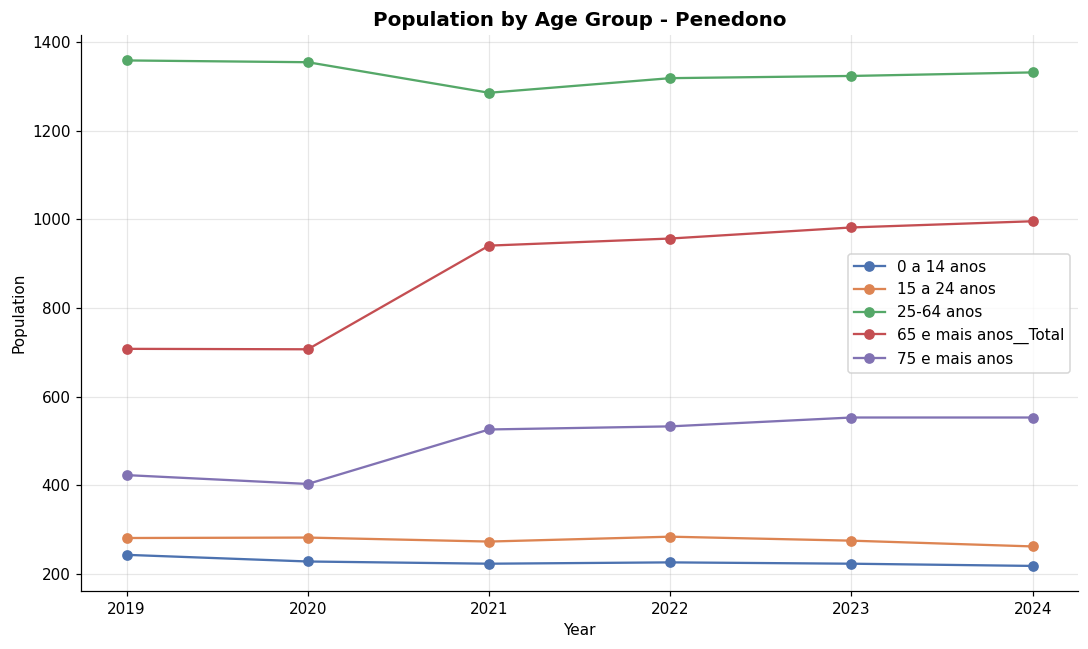

In [10]:
import matplotlib.pyplot as plt

# Set year as index (optional)
df = pop_penedono.set_index("ine_year")

plt.figure(figsize=(10, 6))

for col in ["0 a 14 anos", "15 a 24 anos", "25-64 anos", "65 e mais anos__Total", "75 e mais anos"]:
    plt.plot(df.index, df[col], marker="o", label=col)

plt.title("Population by Age Group - Penedono")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
wildfire_penedono = wildfire_data.loc[
    wildfire_data["year"].between(2001, 2025) &
    (wildfire_data["Concelho"] == "Penedono"),
    ["year", "Num_IncendiosRurais"]
]

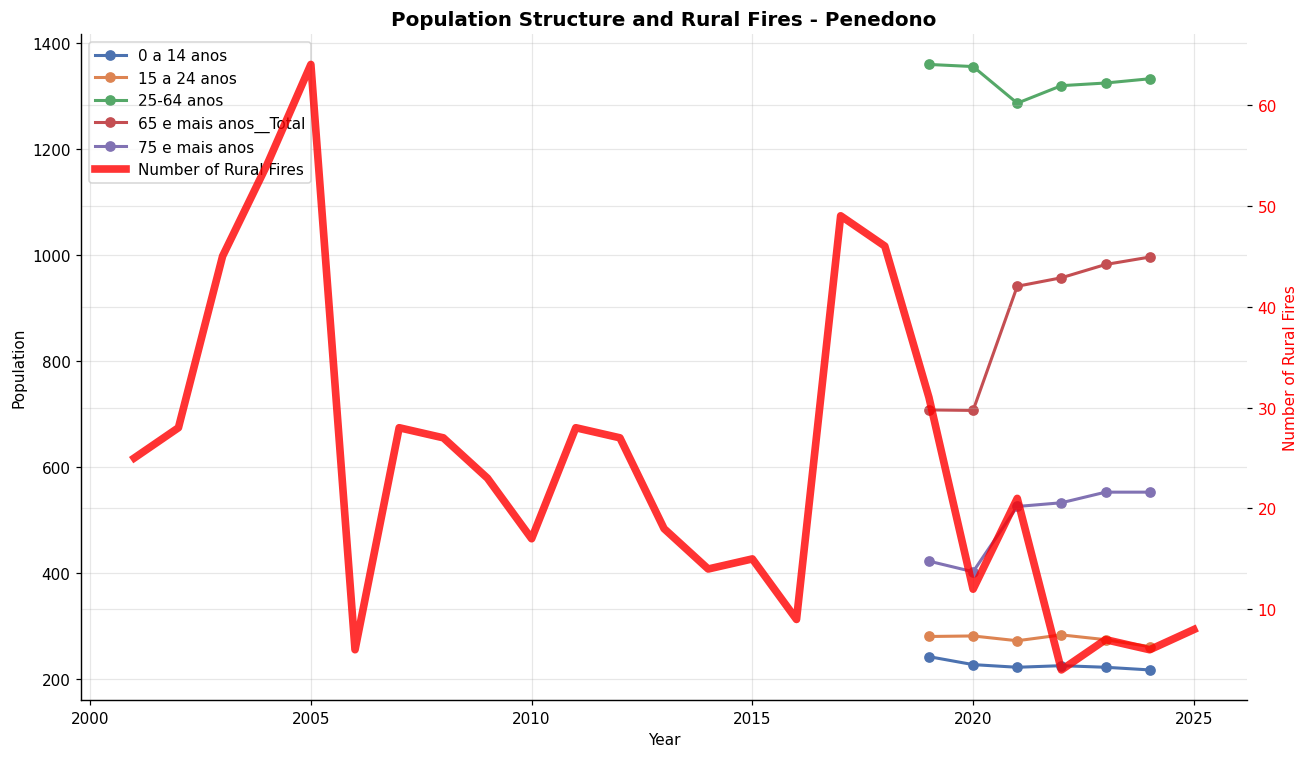

In [14]:
import matplotlib.pyplot as plt

# Population data
pop_df = pop_penedono.set_index("ine_year")

# Fire data
fire_df = wildfire_penedono.set_index("year")

fig, ax1 = plt.subplots(figsize=(12, 7))

# Population lines (left axis)
population_cols = [
    "0 a 14 anos",
    "15 a 24 anos",
    "25-64 anos",
    "65 e mais anos__Total",  # adjust if your actual column name differs
    "75 e mais anos"
]

for col in population_cols:
    ax1.plot(
        pop_df.index,
        pop_df[col],
        marker="o",
        linewidth=2,
        label=col
    )

ax1.set_xlabel("Year")
ax1.set_ylabel("Population")
ax1.grid(True, alpha=0.3)

# Fire axis (right)
ax2 = ax1.twinx()

ax2.plot(
    fire_df.index,
    fire_df["Num_IncendiosRurais"],
    color="red",
    linewidth=5,
    alpha=0.8,
    label="Number of Rural Fires"
)

ax2.set_ylabel("Number of Rural Fires", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Merge legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.title("Population Structure and Rural Fires - Penedono")
plt.tight_layout()
plt.show()

**Conclusion:** Data shows a specific spike in 2021 both in ageing of the population and number of rural fires which may indicate the a link between the two variables or simply chance. However the number of fires was low in 2025, while in reality, the municipality of Penedono was devastated in 2025. Therefore, we conclude that the number of fires may not represent a good metric to represent the damage. Let's investigate other metrics.

### Burned area ratio - Penedono

In this chapter, we investigate the burned area ratio as a severity measure. This metric has been used in scientific research related to socio-economic impact (Chas-Amil et al., 2022 https://www.sciencedirect.com/science/article/pii/S0169204622002262), which is seems adequate to our research question.

In [ ]:
# Build one municipality-year dataset for burned-area ratio and population ageing.
fire_area = wildfire_data[
    [
        "dtcc",
        "year",
        "AreaArdTotal_IncendioInicioConc",
        "AreaArdTotal_NoConcelho",
    ]
].copy()

# ICNF changed the populated total-area field after 2016.
fire_area["burned_area_ha"] = pd.to_numeric(
    fire_area["AreaArdTotal_IncendioInicioConc"], errors="coerce"
).fillna(pd.to_numeric(fire_area["AreaArdTotal_NoConcelho"], errors="coerce"))
fire_area = (
    fire_area.groupby(["dtcc", "year"], as_index=False, dropna=False)["burned_area_ha"]
    .sum(min_count=1)
)

# convert km2 area into ha before calculating the ratio
municipality_area = municipality_dimensions[["dtcc", "municipality", "area_km2"]].copy()
municipality_area["municipality_area_ha"] = municipality_area["area_km2"] * 100

older_population = (
    population_age_data[
        ["dtcc", "ine_year", "65 e mais anos__Total", "75 e mais anos"]
    ]
    .rename(
        columns={
            "ine_year": "year",
            "65 e mais anos__Total": "population_over_65",
            "75 e mais anos": "population_over_75",
        }
    )
    .copy()
)

burned_area_ratio = (
    fire_area
    .merge(municipality_area, on="dtcc", how="left", validate="many_to_one")
    .merge(older_population, on=["dtcc", "year"], how="left", validate="one_to_one")
)
burned_area_ratio["burned_area_ratio"] = (
    burned_area_ratio["burned_area_ha"] / burned_area_ratio["municipality_area_ha"]
)
burned_area_ratio["burned_area_ratio_pct"] = burned_area_ratio["burned_area_ratio"] * 100

burned_area_ratio = burned_area_ratio[
    [
        "dtcc",
        "municipality",
        "year",
        "burned_area_ha",
        "area_km2",
        "municipality_area_ha",
        "burned_area_ratio",
        "burned_area_ratio_pct",
        "population_over_65",
        "population_over_75",
    ]
].sort_values(["municipality", "year"]).reset_index(drop=True)

burned_area_ratio

,dtcc,municipality,year,burned_area_ha,area_km2,municipality_area_ha,burned_area_ratio,burned_area_ratio_pct,population_over_65,population_over_75
0,1401,Abrantes,2001,225.144000,714.69,71469.0,0.003150,0.315023,NaN,NaN
1,1401,Abrantes,2002,105.748100,714.69,71469.0,0.001480,0.147964,NaN,NaN
2,1401,Abrantes,2003,16062.955000,714.69,71469.0,0.224754,22.475416,NaN,NaN
3,1401,Abrantes,2004,1158.198100,714.69,71469.0,0.016206,1.620560,NaN,NaN
4,1401,Abrantes,2005,7645.993600,714.69,71469.0,0.106983,10.698336,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
6916,1012,Óbidos,2021,7.372500,141.55,14155.0,0.000521,0.052084,3213.0,1519.0
6917,1012,Óbidos,2022,2.755000,141.55,14155.0,0.000195,0.019463,3375.0,1617.0
6918,1012,Óbidos,2023,65.990531,141.55,14155.0,0.004662,0.466199,3480.0,1667.0
6919,1012,Óbidos,2024,2.459019,141.55,14155.0,0.000174,0.017372,3558.0,1728.0


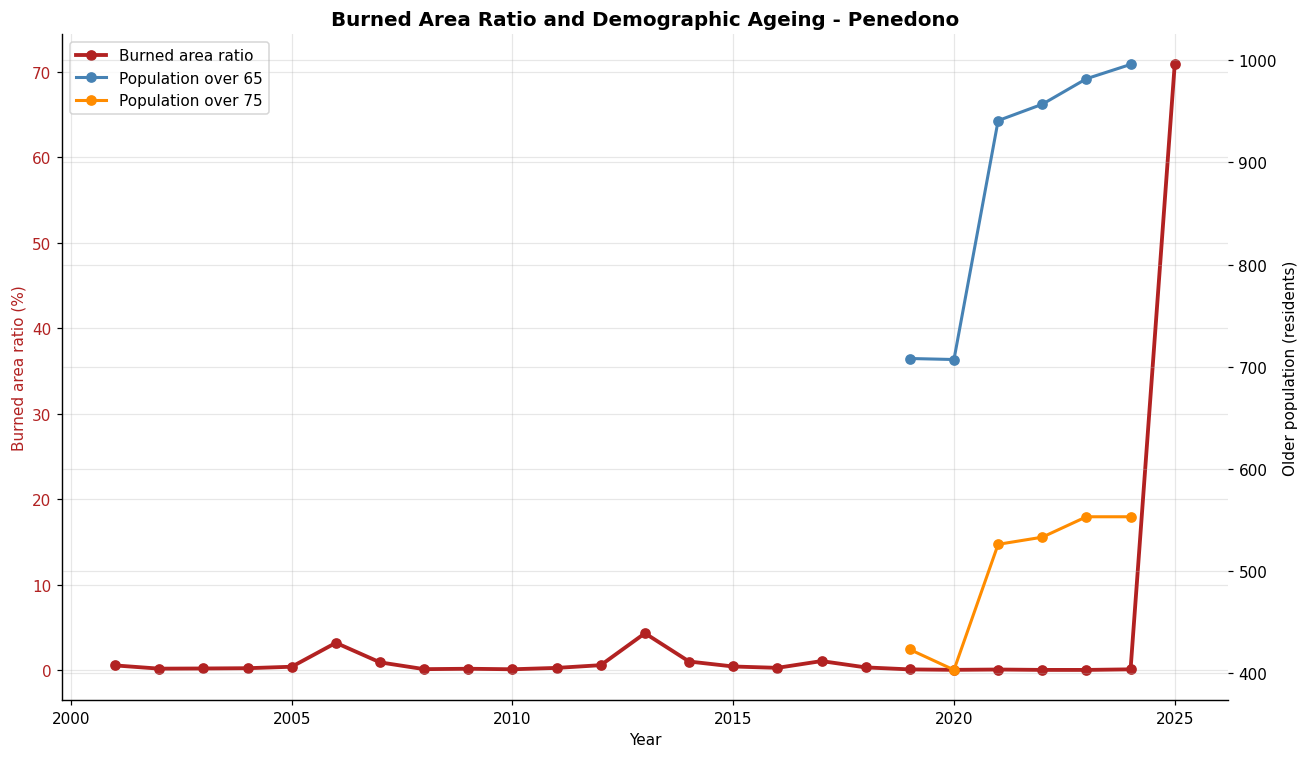

In [30]:
penedono_ratio = burned_area_ratio.loc[
    burned_area_ratio["municipality"].eq("Penedono"),
    ["year", "burned_area_ratio_pct", "population_over_65", "population_over_75"],
].sort_values("year")

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(
    penedono_ratio["year"],
    penedono_ratio["burned_area_ratio_pct"],
    color="firebrick",
    marker="o",
    linewidth=2.5,
    label="Burned area ratio",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Burned area ratio (%)", color="firebrick")
ax1.tick_params(axis="y", labelcolor="firebrick")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    penedono_ratio["year"],
    penedono_ratio["population_over_65"],
    color="steelblue",
    marker="o",
    linewidth=2,
    label="Population over 65",
)
ax2.plot(
    penedono_ratio["year"],
    penedono_ratio["population_over_75"],
    color="darkorange",
    marker="o",
    linewidth=2,
    label="Population over 75",
)
ax2.set_ylabel("Older population (residents)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Burned Area Ratio and Demographic Ageing - Penedono")
fig.tight_layout()
plt.show()

**Conclusion:** The percentage of burned area seems to represent a better metric for the damage caused by the fire (spike in 2025 correspond to the catastrophic fires over the last year). However, we cannot conclude if the demographic ageing after 2020 have contributed to these fires in 2025. Therefore, we should verify if there is a pattern over the country.

### Burned area ratio - Country level

In [31]:
# Build the country-level burned-area ratio and ageing dataset.
portugal_area = municipality_dimensions["area_km2"].sum()
portugal_area_ha = portugal_area * 100

country_burned_area = (
    fire_area.groupby("year", as_index=False)["burned_area_ha"]
    .sum(min_count=1)
)
country_burned_area["portugal_area_km2"] = portugal_area
country_burned_area["portugal_area_ha"] = portugal_area_ha
country_burned_area["burned_area_ratio"] = (
    country_burned_area["burned_area_ha"] / country_burned_area["portugal_area_ha"]
)
country_burned_area["burned_area_ratio_pct"] = (
    country_burned_area["burned_area_ratio"] * 100
)

country_older_population = (
    population_age_data.groupby("ine_year", as_index=False)["65 e mais anos__Total"]
    .sum(min_count=1)
    .rename(
        columns={
            "ine_year": "year",
            "65 e mais anos__Total": "population_over_65",
        }
    )
)

portugal_burned_area_ratio = (
    country_burned_area
    .merge(country_older_population, on="year", how="left", validate="one_to_one")
    [[
        "year",
        "burned_area_ha",
        "portugal_area_km2",
        "portugal_area_ha",
        "burned_area_ratio",
        "burned_area_ratio_pct",
        "population_over_65",
    ]]
    .sort_values("year")
    .reset_index(drop=True)
)

portugal_burned_area_ratio

,year,burned_area_ha,portugal_area_km2,portugal_area_ha,burned_area_ratio,burned_area_ratio_pct,population_over_65
0,2001,117420.438657,92225.18,9222518.0,0.012732,1.273193,NaN
1,2002,130849.078350,92225.18,9222518.0,0.014188,1.418800,NaN
2,2003,471750.049431,92225.18,9222518.0,0.051152,5.115198,NaN
3,2004,151369.876610,92225.18,9222518.0,0.016413,1.641307,NaN
4,2005,346717.819232,92225.18,9222518.0,0.037595,3.759470,NaN
5,2006,83705.863650,92225.18,9222518.0,0.009076,0.907625,NaN
6,2007,36412.547360,92225.18,9222518.0,0.003948,0.394822,NaN
7,2008,19897.219299,92225.18,9222518.0,0.002157,0.215746,NaN
8,2009,92125.662431,92225.18,9222518.0,0.009989,0.998921,NaN
9,2010,140953.185960,92225.18,9222518.0,0.015284,1.528359,NaN


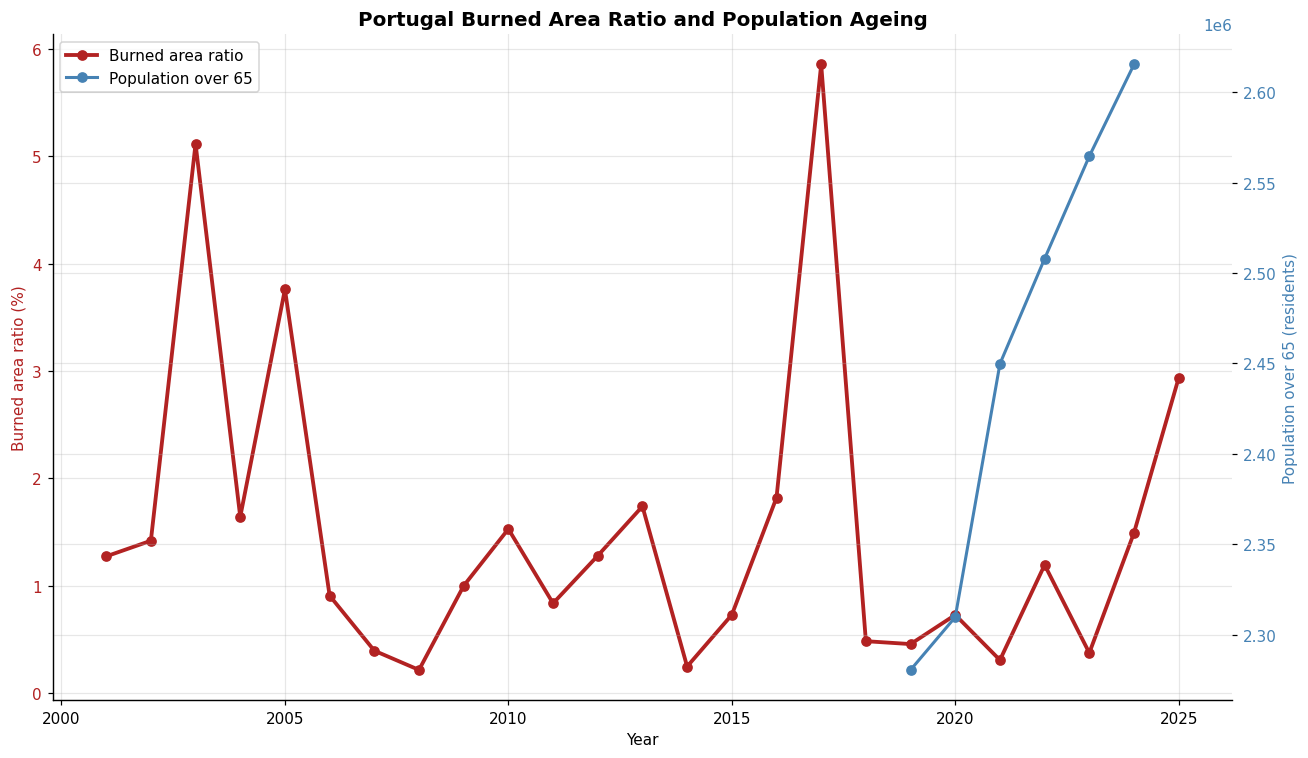

In [32]:
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(
    portugal_burned_area_ratio["year"],
    portugal_burned_area_ratio["burned_area_ratio_pct"],
    color="firebrick",
    marker="o",
    linewidth=2.5,
    label="Burned area ratio",
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Burned area ratio (%)", color="firebrick")
ax1.tick_params(axis="y", labelcolor="firebrick")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    portugal_burned_area_ratio["year"],
    portugal_burned_area_ratio["population_over_65"],
    color="steelblue",
    marker="o",
    linewidth=2,
    label="Population over 65",
)
ax2.set_ylabel("Population over 65 (residents)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title("Portugal Burned Area Ratio and Population Ageing")
fig.tight_layout()
plt.show()

**Conclusion:** Over the country we can observe ciclic patterns of fire damage incidence. The population over 65 is drastically increasing in last years. However, we do not have data about population demographics before 2019, which makes it hard to draw conclusions about the relationship between the two variables.

## Descriptive relationships

In [74]:
# Analysis panel: demographic ageing, rural depopulation, and agricultural fire outcomes.
analysis_panel = wildfire_data[
    [
        "dtcc",
        "year",
        "Num_IncendiosRurais",
        "AreaArdAgric_IncendioInicioConc",
        "AreaArdAgric_NoConcelho",
    ]
].copy()

analysis_panel["agricultural_burned_area_ha"] = pd.to_numeric(
    analysis_panel["AreaArdAgric_IncendioInicioConc"], errors="coerce"
).fillna(pd.to_numeric(analysis_panel["AreaArdAgric_NoConcelho"], errors="coerce"))
analysis_panel["rural_fire_count"] = pd.to_numeric(
    analysis_panel["Num_IncendiosRurais"], errors="coerce"
)
analysis_panel = (
    analysis_panel.groupby(["dtcc", "year"], as_index=False)
    .agg(
        agricultural_burned_area_ha=("agricultural_burned_area_ha", "sum"),
        rural_fire_count=("rural_fire_count", "sum"),
    )
)

analysis_panel = (
    analysis_panel
    .merge(
        municipality_dimensions[["dtcc", "municipality", "area_km2"]],
        on="dtcc",
        how="left",
        validate="many_to_one",
    )
    .merge(
        population_age_data[
            ["dtcc", "ine_year", "Total", "65 e mais anos__Total", "75 e mais anos"]
        ].rename(
            columns={
                "ine_year": "year",
                "Total": "population_total",
                "65 e mais anos__Total": "population_over_65",
                "75 e mais anos": "population_over_75",
            }
        ),
        on=["dtcc", "year"],
        how="inner",
        validate="one_to_one",
    )
)

analysis_panel["municipality_area_ha"] = analysis_panel["area_km2"] * 100
analysis_panel["agri_burned_ratio_pct"] = (
    analysis_panel["agricultural_burned_area_ha"]
    / analysis_panel["municipality_area_ha"]
    * 100
)
analysis_panel["share_over_65"] = (
    analysis_panel["population_over_65"] / analysis_panel["population_total"]
)
analysis_panel["share_over_75"] = (
    analysis_panel["population_over_75"] / analysis_panel["population_total"]
)
analysis_panel = analysis_panel.sort_values(["dtcc", "year"]).reset_index(drop=True)
analysis_panel["population_growth"] = analysis_panel.groupby("dtcc")[
    "population_total"
].pct_change()
analysis_panel["log_fire_count"] = np.log1p(
    analysis_panel["rural_fire_count"].clip(lower=0)
)

analysis_panel = analysis_panel.replace([np.inf, -np.inf], np.nan)
analysis_panel

,dtcc,year,agricultural_burned_area_ha,rural_fire_count,municipality,area_km2,population_total,population_over_65,population_over_75,municipality_area_ha,agri_burned_ratio_pct,share_over_65,share_over_75,population_growth,log_fire_count
0,0101,2019,7.303000,50,Águeda,335.27,46075,11171,5221,33527.0,0.021782,0.242453,0.113315,NaN,3.931826
1,0101,2020,0.909500,30,Águeda,335.27,46349,11425,5391,33527.0,0.002713,0.246499,0.116313,0.005947,3.433987
2,0101,2021,0.580000,28,Águeda,335.27,46247,11969,5741,33527.0,0.001730,0.258806,0.124138,-0.002201,3.367296
3,0101,2022,5.709491,25,Águeda,335.27,46495,12269,5850,33527.0,0.017030,0.263878,0.125820,0.005363,3.258097
4,0101,2023,0.176112,32,Águeda,335.27,47220,12520,6085,33527.0,0.000525,0.265142,0.128865,0.015593,3.496508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1663,1824,2020,0.201600,12,Vouzela,193.69,9623,2795,1584,19369.0,0.001041,0.290450,0.164606,0.000416,2.564949
1664,1824,2021,0.005000,8,Vouzela,193.69,9593,3020,1668,19369.0,0.000026,0.314813,0.173877,-0.003118,2.197225
1665,1824,2022,0.000000,6,Vouzela,193.69,9640,3037,1654,19369.0,0.000000,0.315041,0.171577,0.004899,1.945910
1666,1824,2023,0.050000,7,Vouzela,193.69,9765,3095,1691,19369.0,0.000258,0.316948,0.173169,0.012967,2.079442


## Correlation structure and spurious-correlation checks

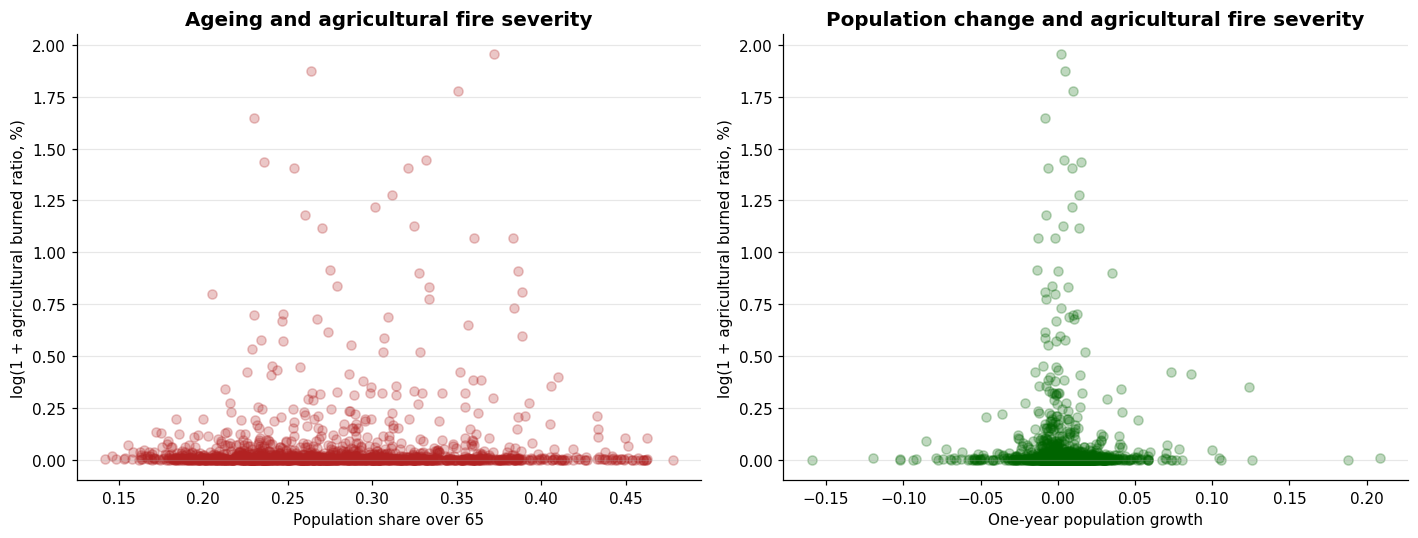

,agri_burned_ratio_pct,log_fire_count,share_over_65,share_over_75,population_growth
agri_burned_ratio_pct,1.000000,0.025127,0.057763,0.038849,-0.007223
log_fire_count,0.025127,1.000000,-0.334031,-0.354736,-0.018657
share_over_65,0.057763,-0.334031,1.000000,0.970564,-0.150988
share_over_75,0.038849,-0.354736,0.970564,1.000000,-0.153637
population_growth,-0.007223,-0.018657,-0.150988,-0.153637,1.000000


In [40]:
# Correlations are descriptive only; municipality and year effects are handled below.
correlation_data = analysis_panel[
    ["agri_burned_ratio_pct", "log_fire_count", "share_over_65", "share_over_75", "population_growth"]
].corr()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(
    analysis_panel["share_over_65"],
    np.log1p(analysis_panel["agri_burned_ratio_pct"]),
    alpha=0.25,
    color="firebrick",
)
axes[0].set_xlabel("Population share over 65")
axes[0].set_ylabel("log(1 + agricultural burned ratio, %)")
axes[0].set_title("Ageing and agricultural fire severity")

axes[1].scatter(
    analysis_panel["population_growth"],
    np.log1p(analysis_panel["agri_burned_ratio_pct"]),
    alpha=0.25,
    color="darkgreen",
)
axes[1].set_xlabel("One-year population growth")
axes[1].set_ylabel("log(1 + agricultural burned ratio, %)")
axes[1].set_title("Population change and agricultural fire severity")

fig.tight_layout()
plt.show()
correlation_data

## Model specification

In [36]:
# Use log1p because agricultural burned-area ratios are strongly right-skewed.
model_data = analysis_panel.copy()
model_data["log_agri_burned_ratio"] = np.log1p(
    model_data["agri_burned_ratio_pct"].clip(lower=0)
)


def fit_fixed_effects(data, predictors, outcome="log_agri_burned_ratio"):
    required = ["dtcc", "year", outcome, *predictors]
    sample = data[required].dropna().copy()
    design = sample[predictors].copy()
    design = pd.concat(
        [
            design,
            pd.get_dummies(sample["dtcc"], prefix="municipality", drop_first=True, dtype=float),
            pd.get_dummies(sample["year"], prefix="year", drop_first=True, dtype=float),
        ],
        axis=1,
    )
    design = sm.add_constant(design.astype(float), has_constant="add")
    fit = sm.OLS(sample[outcome].astype(float), design).fit(
        cov_type="cluster",
        cov_kwds={"groups": sample["dtcc"]},
    )
    return fit, sample, design

ageing_model, ageing_sample, ageing_design = fit_fixed_effects(
    model_data,
    ["share_over_65"],
)
ageing_growth_model, ageing_growth_sample, ageing_growth_design = fit_fixed_effects(
    model_data,
    ["share_over_65", "population_growth"],
)

model_comparison = pd.DataFrame(
    {
        "model": ["Ageing + municipality/year effects", "Ageing + population growth + effects"],
        "observations": [len(ageing_sample), len(ageing_growth_sample)],
        "r_squared": [ageing_model.rsquared, ageing_growth_model.rsquared],
        "share_over_65_coef": [
            ageing_model.params["share_over_65"],
            ageing_growth_model.params["share_over_65"],
        ],
        "share_over_65_pvalue": [
            ageing_model.pvalues["share_over_65"],
            ageing_growth_model.pvalues["share_over_65"],
        ],
        "population_growth_coef": [
            np.nan,
            ageing_growth_model.params["population_growth"],
        ],
        "population_growth_pvalue": [
            np.nan,
            ageing_growth_model.pvalues["population_growth"],
        ],
    }
)
model_comparison

,model,observations,r_squared,share_over_65_coef,share_over_65_pvalue,population_growth_coef,population_growth_pvalue
0,Ageing + municipality/year effects,1668,0.204855,0.668803,0.038153,NaN,NaN
1,Ageing + population growth + effects,1390,0.230435,0.681554,0.074241,0.299197,0.069299


## Panel regression

In [37]:
# Fire-incidence outcome: log(1 + number of rural fires).
fire_incidence_model, fire_incidence_sample, fire_incidence_design = fit_fixed_effects(
    model_data,
    ["share_over_65", "population_growth"],
    outcome="log_fire_count",
)

fire_incidence_results = pd.Series(
    {
        "observations": len(fire_incidence_sample),
        "r_squared": fire_incidence_model.rsquared,
        "share_over_65_coef": fire_incidence_model.params["share_over_65"],
        "share_over_65_pvalue": fire_incidence_model.pvalues["share_over_65"],
        "population_growth_coef": fire_incidence_model.params["population_growth"],
        "population_growth_pvalue": fire_incidence_model.pvalues["population_growth"],
    },
    name="fire_incidence_model",
)
fire_incidence_results

observations                1390.000000
r_squared                      0.855105
share_over_65_coef            -0.666109
share_over_65_pvalue           0.685992
population_growth_coef         0.427809
population_growth_pvalue       0.523134
Name: fire_incidence_model, dtype: float64

## Fire-only time-series forecasting

The demographic panel is limited to 2019-2024. To test whether national fire severity is predictable independently of population variables, this section forecasts Portugal's annual burned-area ratio using only its own history. The 2001-2022 period is used for model development and 2023-2025 is held out for honest evaluation.

In [46]:
# Step 1: define and validate the annual target series.
country_series = (
    portugal_burned_area_ratio.set_index("year")["burned_area_ratio_pct"]
    .sort_index()
    .astype(float)
)
expected_years = pd.Index(range(2001, 2026), name="year")
assert country_series.index.equals(expected_years)
assert country_series.notna().all()

country_series.to_frame("burned_area_ratio_pct").head()

,burned_area_ratio_pct
year,
2001,1.273193
2002,1.418800
2003,5.115198
2004,1.641307
2005,3.759470


### Step 2: chronological train-test split

The model is trained on 2001-2022 and evaluated on the untouched 2023-2025 period. This prevents later observations from influencing model selection and tests whether past fire ratios could anticipate recent years.

In [ ]:
train = country_series.loc[:2022]
test = country_series.loc[2023:2025]

split_summary = pd.DataFrame(
    {
        "period": ["training", "test"],
        "first_year": [train.index.min(), test.index.min()],
        "last_year": [train.index.max(), test.index.max()],
        "observations": [len(train), len(test)],
    }
)
split_summary

### Step 3: inspect autocorrelation and choose differencing

The raw series is non-negative and contains large spikes. We inspect the raw series and its first difference. The ACF/PACF are used as low-order ARIMA guides, not as an automatic high-order parameter search: annual data provides only 22 training observations.

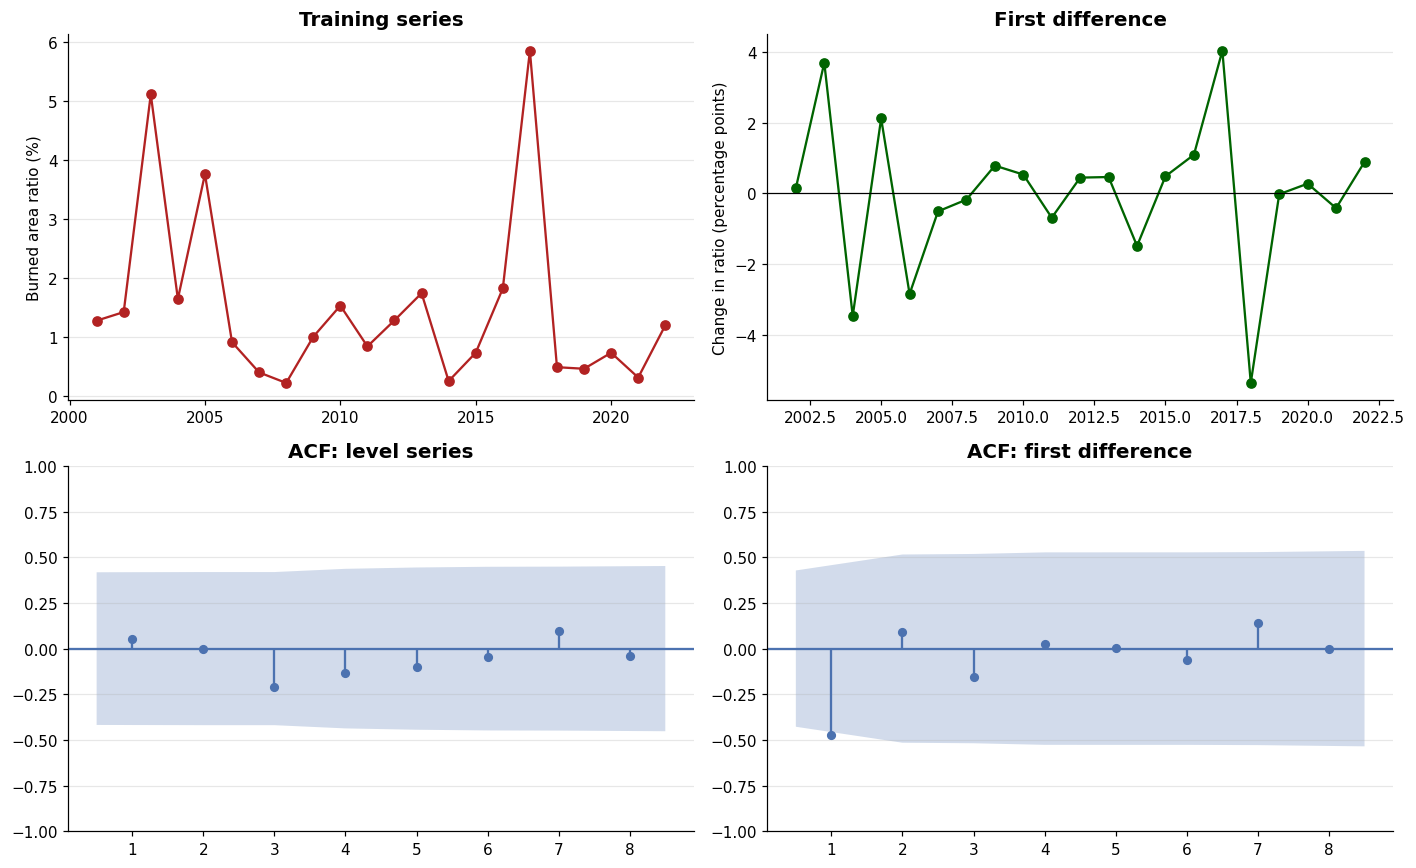

,series,ADF_statistic,ADF_pvalue
0,level,-8.648767,5.183614e-14
1,first_difference,-1.537175,5.150476e-01


In [47]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

raw_adf = adfuller(train, autolag="AIC")
differenced_train = train.diff().dropna()
diff_adf = adfuller(differenced_train, autolag="AIC")

stationarity_checks = pd.DataFrame(
    {
        "series": ["level", "first_difference"],
        "ADF_statistic": [raw_adf[0], diff_adf[0]],
        "ADF_pvalue": [raw_adf[1], diff_adf[1]],
    }
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(train.index, train, marker="o", color="firebrick")
axes[0, 0].set_title("Training series")
axes[0, 0].set_ylabel("Burned area ratio (%)")
axes[0, 1].plot(differenced_train.index, differenced_train, marker="o", color="darkgreen")
axes[0, 1].axhline(0, color="black", linewidth=0.8)
axes[0, 1].set_title("First difference")
axes[0, 1].set_ylabel("Change in ratio (percentage points)")
plot_acf(train, lags=8, ax=axes[1, 0], zero=False)
axes[1, 0].set_title("ACF: level series")
plot_acf(differenced_train, lags=8, ax=axes[1, 1], zero=False)
axes[1, 1].set_title("ACF: first difference")
fig.tight_layout()
plt.show()

stationarity_checks

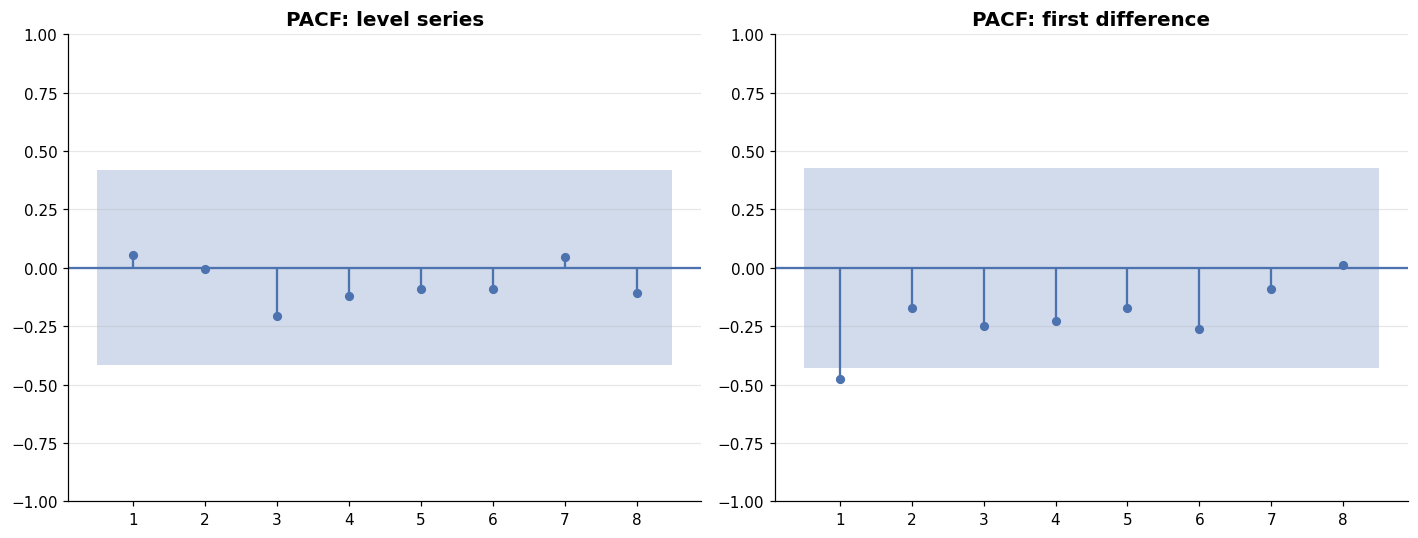

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_pacf(train, lags=8, ax=axes[0], method="ywm", zero=False)
axes[0].set_title("PACF: level series")
plot_pacf(differenced_train, lags=8, ax=axes[1], method="ywm", zero=False)
axes[1].set_title("PACF: first difference")
fig.tight_layout()
plt.show()

### Step 4: translate diagnostics into candidate models

The level ADF test rejects a unit root, so use `d=0`. The level ACF and PACF show no strong low-order spike, so begin with a mean-only model and low-order ARMA alternatives. The differenced plots are retained as a sensitivity check, but they do not justify forcing `d=1`. Because there are only 22 training observations, model selection will use rolling one-step errors rather than a large ARIMA grid.

In [49]:
arima_orders = {
    "ARIMA(0,0,0)": (0, 0, 0),
    "ARIMA(1,0,0)": (1, 0, 0),
    "ARIMA(0,0,1)": (0, 0, 1),
    "ARIMA(1,0,1)": (1, 0, 1),
}


def arima_forecast(series, order, steps=1, alpha=0.05):
    fitted = sm.tsa.ARIMA(series, order=order, trend="c").fit()
    result = fitted.get_forecast(steps=steps)
    mean = np.asarray(result.predicted_mean, dtype=float)
    interval = result.conf_int(alpha=alpha)
    lower = interval.iloc[:, 0].to_numpy(dtype=float)
    upper = interval.iloc[:, 1].to_numpy(dtype=float)
    return mean, lower, upper


def one_step_forecast(series, model_name):
    if model_name == "historical_mean":
        return float(series.mean())
    if model_name == "naive":
        return float(series.iloc[-1])
    return float(arima_forecast(series, arima_orders[model_name])[0][0])

candidate_models = ["historical_mean", "naive", *arima_orders]
candidate_models

['historical_mean',
 'naive',
 'ARIMA(0,0,0)',
 'ARIMA(1,0,0)',
 'ARIMA(0,0,1)',
 'ARIMA(1,0,1)']

### Step 5: select the model with rolling one-step validation

Each candidate is repeatedly fitted using data available up to year $t$ and predicts year $t+1$. This imitates real forecasting and prevents choosing a model because it performs well only on the final holdout.

In [50]:
rolling_rows = []
for model_name in candidate_models:
    actual = []
    predicted = []
    for end_position in range(10, len(train)):
        history = train.iloc[:end_position]
        try:
            prediction = one_step_forecast(history, model_name)
        except (ValueError, np.linalg.LinAlgError):
            prediction = np.nan
        actual.append(float(train.iloc[end_position]))
        predicted.append(prediction)

    rolling_frame = pd.DataFrame({"actual": actual, "predicted": predicted}).dropna()
    rolling_rows.append(
        {
            "model": model_name,
            "validation_observations": len(rolling_frame),
            "MAE": (rolling_frame["predicted"] - rolling_frame["actual"]).abs().mean(),
            "RMSE": np.sqrt(
                ((rolling_frame["predicted"] - rolling_frame["actual"]) ** 2).mean()
            ),
        }
    )

rolling_scores = (
    pd.DataFrame(rolling_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)
selected_model = rolling_scores.iloc[0]["model"]
rolling_scores

c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,validation_observations,MAE,RMSE
0,"ARIMA(0,0,0)",12,1.101621,1.532720
1,historical_mean,12,1.101624,1.532721
2,"ARIMA(0,0,1)",12,1.131423,1.562073
3,"ARIMA(1,0,0)",12,1.141159,1.572413
4,"ARIMA(1,0,1)",12,1.230582,1.637598
5,naive,12,1.305928,2.055459


### Step 6: forecast the held-out years

The selected model is refitted using all training observations through 2022. The final comparison keeps 2023-2025 untouched until this point. Prediction intervals show the range of values compatible with the model, not a guarantee that extreme fires will be covered.

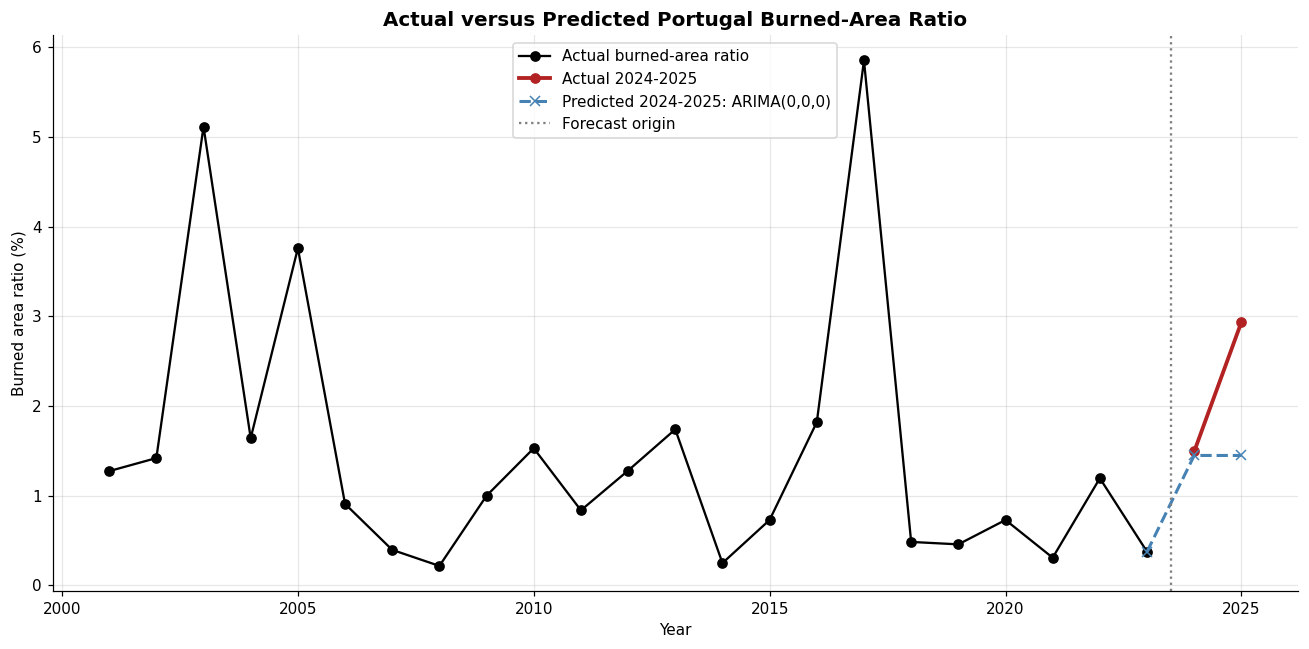

,actual,predicted,absolute_error
year,,,
2024,1.492558,1.44788,0.044678
2025,2.935154,1.44788,1.487274


In [55]:
# Forecast 2024-2025 using fire history available through 2023.
forecast_train = country_series.loc[:2023]
forecast_years = pd.Index([2024, 2025], name="year")

if selected_model == "historical_mean":
    forecast_values = np.repeat(forecast_train.mean(), len(forecast_years))
elif selected_model == "naive":
    forecast_values = np.repeat(forecast_train.iloc[-1], len(forecast_years))
else:
    forecast_values = arima_forecast(
        forecast_train,
        arima_orders[selected_model],
        steps=len(forecast_years),
    )[0]

forecast_2024_2025 = pd.DataFrame(
    {
        "actual": country_series.loc[forecast_years].to_numpy(),
        "predicted": forecast_values,
    },
    index=forecast_years,
)
forecast_2024_2025["absolute_error"] = (
    forecast_2024_2025["actual"] - forecast_2024_2025["predicted"]
).abs()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    country_series.loc[:2023].index,
    country_series.loc[:2023],
    color="black",
    marker="o",
    label="Actual burned-area ratio",
)
ax.plot(
    forecast_2024_2025.index,
    forecast_2024_2025["actual"],
    color="firebrick",
    marker="o",
    linewidth=2.5,
    label="Actual 2024-2025",
)
ax.plot(
    [2023, *forecast_2024_2025.index],
    [country_series.loc[2023], *forecast_2024_2025["predicted"]],
    color="steelblue",
    marker="x",
    linestyle="--",
    linewidth=2,
    label=f"Predicted 2024-2025: {selected_model}",
)
ax.axvline(2023.5, color="grey", linestyle=":", label="Forecast origin")
ax.set_xlabel("Year")
ax.set_ylabel("Burned area ratio (%)")
ax.set_title("Actual versus Predicted Portugal Burned-Area Ratio")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

forecast_2024_2025

### Step 7: diagnose the selected model

The model remains selected by rolling validation, not by the final holdout. The holdout scores are reported for honest evaluation. Residual ACF/PACF and the Ljung-Box test check whether the selected model leaves systematic temporal structure unexplained.

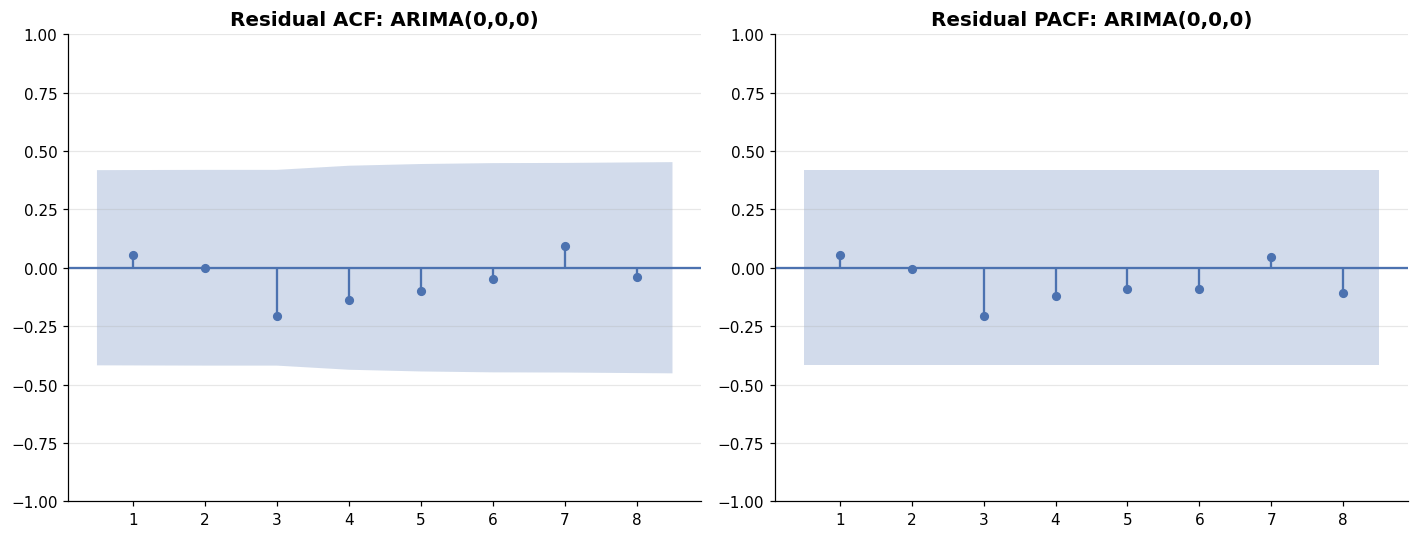

selected_model      ARIMA(0,0,0)
residual_mean           0.000005
residual_std            1.507656
ljung_box_lag                  4
ljung_box_pvalue        0.769139
dtype: object

In [52]:
selected_order = arima_orders[selected_model]
selected_fit = sm.tsa.ARIMA(train, order=selected_order, trend="c").fit()
selected_residuals = selected_fit.resid
ljung_box_lag = min(5, max(1, len(selected_residuals) // 5))
selected_ljung_box = sm.stats.acorr_ljungbox(
    selected_residuals,
    lags=[ljung_box_lag],
    return_df=True,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_acf(selected_residuals, lags=8, ax=axes[0], zero=False)
axes[0].set_title(f"Residual ACF: {selected_model}")
plot_pacf(selected_residuals, lags=8, ax=axes[1], method="ywm", zero=False)
axes[1].set_title(f"Residual PACF: {selected_model}")
fig.tight_layout()
plt.show()

residual_summary = pd.Series(
    {
        "selected_model": selected_model,
        "residual_mean": selected_residuals.mean(),
        "residual_std": selected_residuals.std(),
        "ljung_box_lag": ljung_box_lag,
        "ljung_box_pvalue": selected_ljung_box["lb_pvalue"].iloc[0],
    }
)
residual_summary

### Step 8: time-series conclusion

The diagnostics do not show useful autocorrelation beyond a level mean. The final holdout ranking is descriptive only because it was not used to choose the model. Therefore, the main conclusion is about predictability: past burned-area ratios alone provide a weak baseline for extreme years, not an explanation of why fires occur.

In [56]:
timeseries_conclusion = pd.Series(
    {
        "selected_model": selected_model,
        "selection_rule": "lowest rolling-validation RMSE",
        "rolling_rmse": rolling_scores.loc[
            rolling_scores["model"].eq(selected_model), "RMSE"
        ].iloc[0],
        "forecast_years": "2024-2025",
        "forecast_mae": forecast_2024_2025["absolute_error"].mean(),
        "forecast_2024_error": forecast_2024_2025.loc[2024, "absolute_error"],
        "forecast_2025_error": forecast_2024_2025.loc[2025, "absolute_error"],
        "ljung_box_pvalue": residual_summary["ljung_box_pvalue"],
    }
)
timeseries_conclusion

selected_model                           ARIMA(0,0,0)
selection_rule         lowest rolling-validation RMSE
rolling_rmse                                  1.53272
forecast_years                              2024-2025
forecast_mae                                 0.765976
forecast_2024_error                          0.044678
forecast_2025_error                          1.487274
ljung_box_pvalue                             0.769139
dtype: object

## Robustness checks

In [39]:
# Robustness checks for the main association.
share_75_model, share_75_sample, _ = fit_fixed_effects(
    model_data,
    ["share_over_75", "population_growth"],
)

without_2025_model, without_2025_sample, _ = fit_fixed_effects(
    model_data.loc[model_data["year"] < 2025],
    ["share_over_65", "population_growth"],
)

robustness_results = pd.DataFrame(
    [
        {
            "specification": "Over-65 share, all years",
            "observations": len(ageing_growth_sample),
            "ageing_coefficient": ageing_growth_model.params["share_over_65"],
            "ageing_pvalue": ageing_growth_model.pvalues["share_over_65"],
            "growth_coefficient": ageing_growth_model.params["population_growth"],
            "growth_pvalue": ageing_growth_model.pvalues["population_growth"],
        },
        {
            "specification": "Over-75 share, all years",
            "observations": len(share_75_sample),
            "ageing_coefficient": share_75_model.params["share_over_75"],
            "ageing_pvalue": share_75_model.pvalues["share_over_75"],
            "growth_coefficient": share_75_model.params["population_growth"],
            "growth_pvalue": share_75_model.pvalues["population_growth"],
        },
        {
            "specification": "Over-65 share, excluding 2025",
            "observations": len(without_2025_sample),
            "ageing_coefficient": without_2025_model.params["share_over_65"],
            "ageing_pvalue": without_2025_model.pvalues["share_over_65"],
            "growth_coefficient": without_2025_model.params["population_growth"],
            "growth_pvalue": without_2025_model.pvalues["population_growth"],
        },
    ]
)
robustness_results

,specification,observations,ageing_coefficient,ageing_pvalue,growth_coefficient,growth_pvalue
0,"Over-65 share, all years",1390,0.681554,0.074241,0.299197,0.069299
1,"Over-75 share, all years",1390,0.927170,0.148286,0.291092,0.076003
2,"Over-65 share, excluding 2025",1390,0.681554,0.074241,0.299197,0.069299


## Research question: interpretation, conclusions, and limitations

In [57]:
# Evidence-based interpretation of the demographic panel and fire-only time series.
interpretation = {
    "panel_scope": (
        f"The panel contains {len(analysis_panel):,} municipality-year observations "
        "for 2019-2024, the years with comparable demographic data."
    ),
    "agricultural_severity": (
        "The over-65 share has a positive association with log agricultural burned-area "
        f"severity (coefficient={ageing_growth_model.params['share_over_65']:.3f}, "
        f"p={ageing_growth_model.pvalues['share_over_65']:.3f}), but the evidence is "
        "not conventionally strong after controlling for population growth and fixed effects."
    ),
    "rural_depopulation": (
        "Population growth is not clearly associated with agricultural burned-area severity "
        f"(coefficient={ageing_growth_model.params['population_growth']:.3f}, "
        f"p={ageing_growth_model.pvalues['population_growth']:.3f})."
    ),
    "fire_incidence": (
        "Neither ageing nor population growth explains log rural-fire counts in the "
        f"fixed-effects model (ageing p={fire_incidence_model.pvalues['share_over_65']:.3f}; "
        f"growth p={fire_incidence_model.pvalues['population_growth']:.3f})."
    ),
    "forecasting": (
        f"Rolling validation selected {selected_model}. The 2024-2025 point forecast "
        f"has mean absolute error {forecast_2024_2025['absolute_error'].mean():.3f}; "
        f"the 2025 error is {forecast_2024_2025.loc[2025, 'absolute_error']:.3f}, "
        "showing that fire history alone did not anticipate the extreme year."
    ),
    "overall_conclusion": (
        "The demographic results are exploratory rather than causal. The fire-only time "
        "series has little exploitable temporal structure and did not anticipate the 2025 "
        "extreme. Weather, land management, ignition sources, and vegetation conditions "
        "are important omitted factors."
    ),
}
for statement in interpretation.values():
    print(statement)

The panel contains 1,668 municipality-year observations for 2019-2024, the years with comparable demographic data.
The over-65 share has a positive association with log agricultural burned-area severity (coefficient=0.682, p=0.074), but the evidence is not conventionally strong after controlling for population growth and fixed effects.
Population growth is not clearly associated with agricultural burned-area severity (coefficient=0.299, p=0.069).
Neither ageing nor population growth explains log rural-fire counts in the fixed-effects model (ageing p=0.686; growth p=0.523).
Rolling validation selected ARIMA(0,0,0). The 2024-2025 point forecast has mean absolute error 0.766; the 2025 error is 1.487, showing that fire history alone did not anticipate the extreme year.
The demographic results are exploratory rather than causal. The fire-only time series has little exploitable temporal structure and did not anticipate the 2025 extreme. Weather, land management, ignition sources, and vegetat

## Overall conclusion

The research question asks whether demographic ageing and rural depopulation are related to fire incidence in agricultural areas. The analysis provides **some suggestive but inconclusive evidence for agricultural fire severity**, and little evidence for the number of fires themselves.

The municipality panel covers 2019-2024 and contains 1,668 municipality-year observations. In the fixed-effects model, the share of residents over 65 has a positive coefficient for log agricultural burned-area severity, but the association becomes statistically uncertain after population growth is added. The over-65 coefficient is approximately 0.682 with a p-value of 0.074. The over-75 robustness model is also positive but less precise. Population growth, used as a proxy for rural depopulation, has a positive but borderline association with agricultural burned-area severity, with a coefficient of approximately 0.299 and a p-value of 0.069.

These results should not be interpreted as proof that ageing or depopulation increases agricultural fire damage. They also should not be interpreted as proof that no relationship exists. The appropriate conclusion is that this dataset and model do not provide sufficiently strong evidence to establish the relationship.

The distinction between **fire incidence** and **fire severity** is important. In the fire-count model, neither the over-65 share nor population growth is clearly associated with the number of rural fires: the p-values are approximately 0.686 and 0.523. Demographic change may therefore be more plausibly related to land management, fuel accumulation, or the consequences of a fire once it starts than to the probability that an ignition occurs. The current results cannot distinguish these mechanisms.

The country-level time-series analysis reaches a complementary conclusion. Fire history alone contains little stable temporal structure. Rolling validation selected a mean-level forecast, and the final point forecasts did not anticipate the 2025 extreme. This does not contradict the panel analysis: the time series answers whether national fire severity is predictable from its own past, while the panel asks whether differences between municipalities and years are associated with demographic conditions.

## Why the link may not appear

Several explanations are possible:

- The demographic period is short. Comparable municipality-level age data is available only from 2019-2024, giving six years and only five annual population changes per municipality.
- Ageing and depopulation may operate through delayed mechanisms. Land abandonment, reduced agricultural maintenance, and fuel accumulation may affect fire risk over many years rather than immediately.
- Absolute counts may hide the mechanism. The model uses ageing shares and population growth, but it does not directly measure abandoned agricultural land, unmanaged vegetation, grazing, road access, or firefighting capacity.
- Fire incidence and burned area are noisy outcomes. Weather, drought, wind, ignition source, suppression response, and reporting practices can dominate demographic effects in individual years.
- The ICNF fire area variables changed across the historical data structure, and the national denominator may not perfectly match the mainland geography covered by the fire statistics.
- A weak statistical result can reflect limited power, measurement error, omitted variables, or a genuinely small effect. The p-values near 0.07 are compatible with an uncertain signal, not a definitive null result.

## Is the conclusion definitive?

No. It is a qualified, data-bound conclusion. The analysis rejects neither the demographic mechanism nor the possibility that its effect is small, delayed, indirect, or concentrated in particular municipalities. The absence of a clear relationship in the fire-count model is stronger evidence against a simple direct relationship with the number of fires, but it is not evidence against all demographic pathways.

The fixed-effects specification improves the analysis by controlling for time-invariant municipality characteristics and national year shocks. However, it does not control for time-varying weather, drought, land cover, agricultural abandonment, ignition sources, or suppression effort. The coefficient on ageing should therefore be read as an association conditional on the included controls, not as a causal effect.

## Analyses needed to confirm or refute the relationship

A stronger test would require:

1. **Longer demographic histories.** Add the 2011 and 2021 censuses, annual population estimates, and historical age structure. Do not simulate pre-2019 data for the primary model.
2. **Better depopulation measures.** Add total population change, working-age population change, housing vacancy, agricultural employment, land abandonment, and cultivated-area change.
3. **Mechanism variables.** Measure shrub encroachment, vegetation continuity, agricultural land cover, grazing, road density, distance to settlements, and firefighting resources.
4. **Weather and drought controls.** Include temperature, precipitation deficit, wind, drought indices, and soil moisture at municipality-year or finer resolution.
5. **Distributed lags.** Test whether demographic change affects burned area after one or more years. A lagged panel model is more plausible than assuming an immediate effect.
6. **Alternative outcomes.** Estimate separate models for fire count, agricultural burned area, total burned area, large-fire occurrence, and burned-area ratio. This separates ignition, spread, and severity mechanisms.
7. **Stratified and nonlinear models.** Test whether the relationship differs between rural and urban municipalities, agricultural intensity groups, or municipalities above a threshold of ageing.
8. **Out-of-sample validation.** Use spatial and temporal holdouts to test whether demographic variables improve prediction beyond weather and historical fire baselines.

The most defensible future design is a longer municipality-year panel with municipality and year fixed effects, clustered standard errors, distributed demographic lags, and time-varying weather and land-management controls. If the ageing and depopulation coefficients remain stable across those specifications, the evidence for a relationship becomes stronger. If they disappear after adding these controls, the original association was likely confounded or too indirect to identify with the current data.

## Takeaways

- The 2019-2024 panel shows a positive but uncertain association between demographic ageing and agricultural burned-area severity.
- The analysis does not show a clear relationship between ageing or population growth and the number of rural fires.
- These are not definitive null findings: the demographic time window is short, and key mechanisms such as land abandonment, fuel accumulation, weather, drought, and suppression are not measured.
- Fire-only time-series models provide a weak baseline and do not anticipate extreme years such as 2025.
- Confirming or refuting the relationship requires a longer demographic panel, distributed demographic lags, and time-varying weather and land-management controls.

## Rural versus non-rural fire analysis

This section compares fire outcomes between rural and non-rural municipalities. A municipality is classified as rural when its population density is below 300 residents per km2. The classification is based on the 2022 density snapshot and is treated as stable across years. This is an analytical convention, not an official Portuguese rural classification.

The analysis uses 2019-2024 because those are the years with comparable INE population-density data. Fire incidence and fire severity are kept separate: `Num_IncendiosRurais` measures recorded rural fires, while burned-area variables measure fire damage.

### 1. Load and validate population density

In [64]:
from wildfires.clean import normalise_name

density_years = range(STUDY_YEARS[0], STUDY_YEARS[1] + 1)
population_density_data = load_ine_population_all(years=density_years)
population_density = population_density_data[["municipality", "ine_year", "pop_density"]].copy()
population_density = population_density.rename(columns={"ine_year": "year"})
population_density["pop_density"] = pd.to_numeric(
    population_density["pop_density"], errors="coerce"
)
population_density["municipality_key"] = normalise_name(population_density["municipality"])

municipality_lookup = municipality_dimensions[["dtcc", "municipality"]].drop_duplicates().copy()
municipality_lookup["municipality_key"] = normalise_name(municipality_lookup["municipality"])
lookup_counts = municipality_lookup.groupby("municipality_key")["dtcc"].nunique()
unique_keys = lookup_counts[lookup_counts.eq(1)].index
municipality_lookup = municipality_lookup[
    municipality_lookup["municipality_key"].isin(unique_keys)
]
population_density = population_density.merge(
    municipality_lookup[["dtcc", "municipality_key"]],
    on="municipality_key",
    how="left",
    validate="many_to_one",
)
population_density = population_density.dropna(subset=["dtcc"])
population_density = population_density.drop_duplicates(["dtcc", "year", "pop_density"])

assert set(population_density["year"].dropna().unique()) == set(density_years)
assert not population_density.duplicated(["dtcc", "year"]).any()
assert (population_density["pop_density"].dropna() >= 0).all()

pd.Series(
    {
        "density_rows": len(population_density),
        "mapped_rows": population_density["dtcc"].notna().sum(),
        "ambiguous_name_keys_excluded": (~lookup_counts.eq(1)).sum(),
    }
)

c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: II_01_01!$A:$O.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: II_01_06c!$A:$P.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'II_01 02'!$A:$S.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workbook.py:118: UserWarning: Print area cannot be set to Defined name: 'II_01 04'!$A:$J.
  warn(f"Print area cannot be set to Defined name: {defn.value}.")
c:\Users\Manue\Documents\nosql_lab\venv\Lib\site-packages\openpyxl\reader\workb

density_rows                    1824
mapped_rows                     1824
ambiguous_name_keys_excluded       2
dtype: int64

### 2. Create the stable 2022 rural classification

In [65]:
rural_threshold = 300
rural_reference = (
    population_density.loc[population_density["year"].eq(2022), ["dtcc", "pop_density"]]
    .rename(columns={"pop_density": "population_density_2022"})
    .drop_duplicates("dtcc")
)
rural_reference["is_rural"] = rural_reference["population_density_2022"].lt(rural_threshold)
rural_reference["rural_class"] = np.where(
    rural_reference["is_rural"], "rural", "non-rural"
)

assert rural_reference["dtcc"].is_unique
assert rural_reference["population_density_2022"].notna().all()
assert (rural_reference["population_density_2022"] >= 0).all()

rural_reference["rural_class"].value_counts()

rural_class
rural        251
non-rural     53
Name: count, dtype: int64

### 3. Join rurality to the 2019-2024 fire panel

In [67]:
rural_fire_panel = analysis_panel.merge(
    rural_reference,
    on="dtcc",
    how="left",
    validate="many_to_one",
)
rural_fire_panel = rural_fire_panel[
    rural_fire_panel["year"].between(min(density_years), max(density_years))
].copy()

assert not rural_fire_panel.duplicated(["dtcc", "year"]).any()

rural_panel_coverage = (
    rural_fire_panel.groupby("year")
    .agg(
        observations=("dtcc", "size"),
        mapped_observations=("rural_class", lambda values: values.notna().sum()),
        unmapped_observations=("rural_class", lambda values: values.isna().sum()),
    )
    .reset_index()
)
rural_fire_panel = rural_fire_panel[rural_fire_panel["rural_class"].notna()].copy()
rural_panel_coverage

,year,observations,mapped_observations,unmapped_observations
0,2019,278,277,1
1,2020,278,277,1
2,2021,278,277,1
3,2022,278,277,1
4,2023,278,277,1
5,2024,278,277,1


### 4. Rural and non-rural outcome summaries

In [68]:
rural_outcome_diagnostics = (
    rural_fire_panel.groupby(["year", "rural_class"])
    .agg(
        municipalities=("dtcc", "nunique"),
        observations=("dtcc", "size"),
        missing_fire_count=("rural_fire_count", lambda values: values.isna().sum()),
        zero_fire_share=("rural_fire_count", lambda values: values.eq(0).mean()),
        mean_fire_count=("rural_fire_count", "mean"),
        median_fire_count=("rural_fire_count", "median"),
        mean_agri_burned_ha=("agricultural_burned_area_ha", "mean"),
        median_agri_burned_ha=("agricultural_burned_area_ha", "median"),
        mean_agri_ratio_pct=("agri_burned_ratio_pct", "mean"),
        median_agri_ratio_pct=("agri_burned_ratio_pct", "median"),
    )
    .reset_index()
)
rural_outcome_diagnostics

,year,rural_class,municipalities,observations,missing_fire_count,zero_fire_share,mean_fire_count,median_fire_count,mean_agri_burned_ha,median_agri_burned_ha,mean_agri_ratio_pct,median_agri_ratio_pct
0,2019,non-rural,50,50,0,0.020000,63.140000,38.0,2.095583,0.662000,0.021122,0.005489
1,2019,rural,227,227,0,0.000000,33.766520,24.0,20.414173,2.423600,0.045185,0.008050
2,2020,non-rural,50,50,0,0.020000,66.900000,41.5,1.294715,0.283650,0.008242,0.003203
3,2020,rural,227,227,0,0.000000,27.621145,17.0,28.309602,1.459000,0.058491,0.005976
4,2021,non-rural,50,50,0,0.000000,47.880000,38.5,9.820368,0.417752,0.134119,0.003387
5,2021,rural,227,227,0,0.000000,25.449339,16.0,11.183530,0.845000,0.026360,0.002749
6,2022,non-rural,50,50,0,0.000000,62.580000,32.0,3.087318,0.478675,0.018661,0.005222
7,2022,rural,227,227,0,0.013216,31.942731,18.0,47.897799,2.395300,0.145862,0.008531
8,2023,non-rural,50,50,0,0.000000,42.520000,28.0,1.920085,0.385200,0.011813,0.003430
9,2023,rural,227,227,0,0.004405,23.748899,13.0,8.844174,0.878500,0.018648,0.002962


### 5. Visual comparison of rural and non-rural outcomes

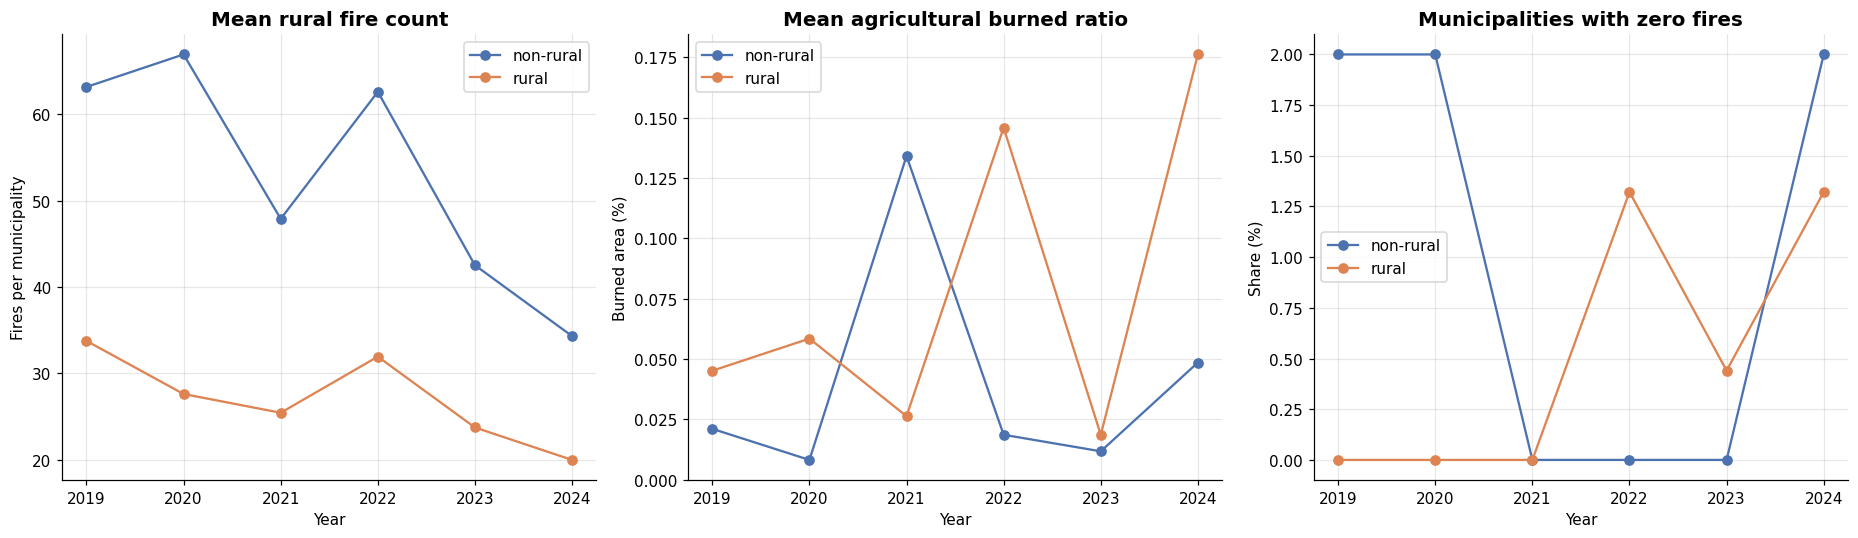

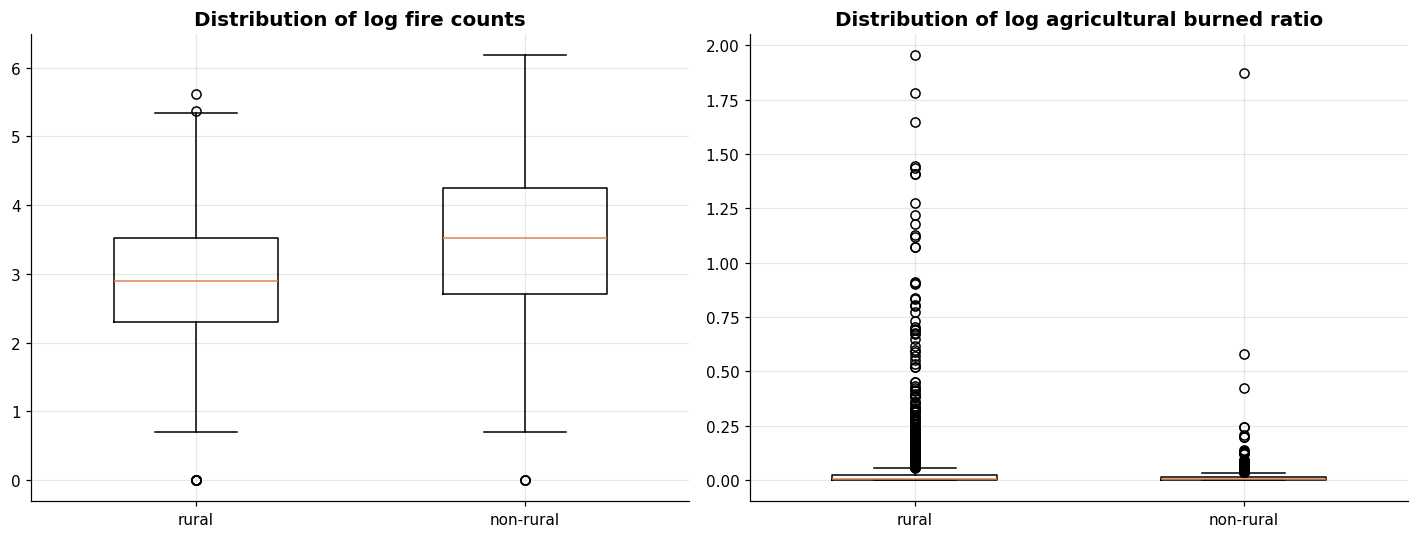

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for rural_class, group in rural_outcome_diagnostics.groupby("rural_class"):
    axes[0].plot(
        group["year"], group["mean_fire_count"], marker="o", label=rural_class
    )
    axes[1].plot(
        group["year"], group["mean_agri_ratio_pct"], marker="o", label=rural_class
    )
    axes[2].plot(
        group["year"], group["zero_fire_share"] * 100, marker="o", label=rural_class
    )

axes[0].set_title("Mean rural fire count")
axes[0].set_ylabel("Fires per municipality")
axes[1].set_title("Mean agricultural burned ratio")
axes[1].set_ylabel("Burned area (%)")
axes[2].set_title("Municipalities with zero fires")
axes[2].set_ylabel("Share (%)")
for axis in axes:
    axis.set_xlabel("Year")
    axis.grid(True, alpha=0.3)
    axis.legend()
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for rural_class, group in rural_fire_panel.groupby("rural_class"):
    class_position = 0 if rural_class == "rural" else 1
    axes[0].boxplot(
        group["log_fire_count"].dropna(),
        positions=[class_position],
        widths=0.5,
    )
    axes[1].boxplot(
        np.log1p(group["agri_burned_ratio_pct"].clip(lower=0).dropna()),
        positions=[class_position],
        widths=0.5,
    )
for axis, title in zip(
    axes,
    ["Distribution of log fire counts", "Distribution of log agricultural burned ratio"],
):
    axis.set_xticks([0, 1], labels=["rural", "non-rural"])
    axis.set_title(title)
    axis.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 6. Rural differences with municipality and year effects

In [70]:
rural_model_data = rural_fire_panel.copy()
rural_model_data["log_agri_ratio"] = np.log1p(
    rural_model_data["agri_burned_ratio_pct"].clip(lower=0)
)
rural_model_data["is_rural_numeric"] = rural_model_data["rural_class"].eq("rural").astype(float)


def fit_rural_interaction(data, outcome):
    sample = data[["dtcc", "year", "is_rural_numeric", outcome]].dropna().copy()
    year_dummies = pd.get_dummies(sample["year"], prefix="year", drop_first=True, dtype=float)
    municipality_dummies = pd.get_dummies(
        sample["dtcc"], prefix="municipality", drop_first=True, dtype=float
    )
    interactions = year_dummies.mul(sample["is_rural_numeric"].to_numpy(), axis=0)
    interactions.columns = [f"rural_{column}" for column in year_dummies.columns]
    design = pd.concat(
        [year_dummies, municipality_dummies, interactions], axis=1
    )
    design = sm.add_constant(design.astype(float), has_constant="add")
    fit = sm.OLS(sample[outcome].astype(float), design).fit(
        cov_type="cluster",
        cov_kwds={"groups": sample["dtcc"]},
    )
    return fit, sample

severity_rural_model, severity_rural_sample = fit_rural_interaction(
    rural_model_data,
    "log_agri_ratio",
)
incidence_rural_model, incidence_rural_sample = fit_rural_interaction(
    rural_model_data,
    "log_fire_count",
)

rural_effects = pd.DataFrame(
    {
        "outcome": ["log agricultural burned ratio", "log rural fire count"],
        "observations": [len(severity_rural_sample), len(incidence_rural_sample)],
        "rural_2024_interaction": [
            severity_rural_model.params.get("rural_year_2024", np.nan),
            incidence_rural_model.params.get("rural_year_2024", np.nan),
        ],
        "rural_2024_pvalue": [
            severity_rural_model.pvalues.get("rural_year_2024", np.nan),
            incidence_rural_model.pvalues.get("rural_year_2024", np.nan),
        ],
        "r_squared": [severity_rural_model.rsquared, incidence_rural_model.rsquared],
    }
)
rural_effects

,outcome,observations,rural_2024_interaction,rural_2024_pvalue,r_squared
0,log agricultural burned ratio,1662,0.042228,0.124979,0.209961
1,log rural fire count,1662,0.232246,0.105939,0.851357


### 7. Sensitivity analysis with year-specific rurality

In [71]:
time_varying_rurality = analysis_panel.merge(
    population_density[["dtcc", "year", "pop_density"]],
    on=["dtcc", "year"],
    how="left",
    validate="one_to_one",
)
time_varying_rurality["is_rural_year"] = time_varying_rurality["pop_density"].lt(
    rural_threshold
)
time_varying_rurality["rural_class_year"] = np.where(
    time_varying_rurality["is_rural_year"], "rural", "non-rural"
)
time_varying_rurality = time_varying_rurality.dropna(subset=["pop_density"]).copy()

stable_labels = rural_reference[["dtcc", "rural_class"]].rename(
    columns={"rural_class": "stable_rural_class"}
)
time_varying_rurality = time_varying_rurality.merge(
    stable_labels,
    on="dtcc",
    how="left",
    validate="many_to_one",
)
time_varying_rurality["classification_switch"] = (
    time_varying_rurality["rural_class_year"]
    != time_varying_rurality["stable_rural_class"]
)

classification_stability = pd.Series(
    {
        "observations": len(time_varying_rurality),
        "municipalities": time_varying_rurality["dtcc"].nunique(),
        "classification_switches": time_varying_rurality["classification_switch"].sum(),
        "switch_share": time_varying_rurality["classification_switch"].mean(),
    }
)
classification_stability

observations               1385.000000
municipalities              277.000000
classification_switches       4.000000
switch_share                  0.002888
dtype: float64

### 8. Interpretation and limitations of the rural comparison

The stable 2022 density rule produces 251 rural and 53 non-rural municipalities in the reference table. In the 2019-2024 ICNF panel, rural municipalities have lower average recorded fire counts but generally higher agricultural burned-area ratios. This distinction matters: rurality may be more closely related to the amount of agricultural land exposed, fuel continuity, or fire spread than to the number of ignition events.

The municipality and year fixed-effects interaction model does not provide strong evidence of a different rural trend by 2024. The rural-by-2024 interaction is positive for both agricultural burned-area severity and fire counts, but its p-values are above conventional significance thresholds. The result is therefore descriptive and uncertain, not proof that rural and non-rural municipalities have the same fire dynamics.

The classification is highly stable in the available density data: only a very small share of mapped municipality-year observations changes class when each year's density is used instead of the stable 2022 label. This supports the stable-label convention, but it does not solve the larger limitations. Population density does not measure agricultural abandonment, vegetation fuel, land management, weather, drought, ignition sources, or suppression capacity. The 300 residents/km2 threshold is also arbitrary from a causal perspective.

The comparison should therefore be read as: within the 2019-2024 matched sample, rural municipalities show different descriptive fire profiles, especially for agricultural burned-area severity, but the analysis cannot identify why those differences exist. Confirmation would require longer demographic histories, land-use and abandonment measures, weather and drought controls, spatially clustered uncertainty, distributed lags, and out-of-sample validation. It would also be useful to repeat the analysis with alternative density thresholds and continuous population density rather than relying on one cutoff.